In [1]:
import numpy as np
import gpt as g
import matplotlib.pyplot as plt

SharedMemoryNone: SharedMemoryAllocate 1073741824 GPU implementation 
0SharedMemoryNone:  SharedMemoryNone.cc acceleratorAllocDevice 1073741824bytes at 0x300000000 for comms buffers 

__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|_ |  |  |  |  |  |  |  |  |  |  |  | _|__
__|_                                    _|__
__|_   GGGG    RRRR    III    DDDD      _|__
__|_  G        R   R    I     D   D     _|__
__|_  G        R   R    I     D    D    _|__
__|_  G  GG    RRRR     I     D    D    _|__
__|_  G   G    R  R     I     D   D     _|__
__|_   GGGG    R   R   III    DDDD      _|__
__|_                                    _|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
  |  |  |  |  |  |  |  |  |  |  |  |  |  |  


Copyright (C) 2015 Peter Boyle, Azusa Yamaguchi, Guido Cossu, Antonin Portelli and other authors

This program is free software; you can redistribute it and/or modify
it under the term

In [2]:
size = 2
grid = g.grid([size, size], g.double)
rng = g.random("t")

K = g.qcd.gauge.unit(grid)
rng.normal_element(K)

GPT :       0.753818 s : Initializing gpt.random(t,vectorized_ranlux24_389_64) took 0.000369072 s


[lattice(ot_matrix_su_n_fundamental_group(3),double),
 lattice(ot_matrix_su_n_fundamental_group(3),double)]

In [3]:
a = g(g.trace(K))
a[1][1,1] - a[1][:][1]

array([-0.67226569+0.04362893j])

In [4]:
def H(U):
    traces = g(g.trace(U))
    Ham = traces[0][0,0] + traces[1][0,0]
    return Ham.real / 3.

In [5]:
H(K)

1.127904824972434

In [6]:
def updateQ(U, eps = 0.1):
    eps /=3.
    U[0] = g( g.matrix.exp( eps * g.qcd.gauge.project.traceless_anti_hermitian( U[1] )) * U[0] )
    return U

def updateP(U, eps = 0.1):
    eps /=3.
    U[1] = g( g.matrix.exp( - eps * g.qcd.gauge.project.traceless_anti_hermitian( U[0] )) * U[1] )
    return U

In [15]:
U = g.copy(K)

energies = []
energies.append( H(U) )

eps = 0.5

#U = updateQ(U, eps/2.)

for i in range(100):
    U = updateP(U, eps/2.)
    U = updateQ(U, eps)
    U = updateP(U, eps/2.)
    #if i % 4 == 0:
    energies.append( H(U) )
    

#U = updateP(U, eps)
#U = updateQ(U,eps/2.)

<>:1: SyntaxWarning: invalid escape sequence '\e'
<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:1: SyntaxWarning: invalid escape sequence '\e'
<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
/var/folders/d2/bw8ht0dn1pn7t1cyl1mlth7w0000gn/T/ipykernel_36720/1279377560.py:1: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(np.arange(0,len(energies))*0.5, [x.real for x in energies], label='$\epsilon = 0.5$')
/var/folders/d2/bw8ht0dn1pn7t1cyl1mlth7w0000gn/T/ipykernel_36720/1279377560.py:2: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(np.arange(0,len(energies1))*0.5, [x.real for x in energies1], label='$\epsilon = 0.25$')
/var/folders/d2/bw8ht0dn1pn7t1cyl1mlth7w0000gn/T/ipykernel_36720/1279377560.py:3: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(np.arange(0,len(energies2))*0.5, [x.real for x in energies2], label='$\epsilon = 0.125$')


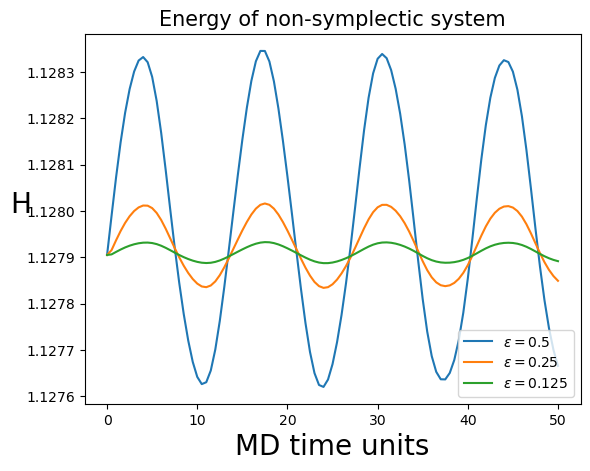

In [27]:
plt.plot(np.arange(0,len(energies))*0.5, [x.real for x in energies], label='$\epsilon = 0.5$')
plt.plot(np.arange(0,len(energies1))*0.5, [x.real for x in energies1], label='$\epsilon = 0.25$')
plt.plot(np.arange(0,len(energies2))*0.5, [x.real for x in energies2], label='$\epsilon = 0.125$')
plt.legend()
plt.ylabel("H", rotation='horizontal', size=20)
plt.xlabel("MD time units", size=20)
plt.title("Energy of non-symplectic system", size=15)
#plt.savefig("non-sym-energy.pdf")